In [1]:
import jax
import jax.numpy as jnp
from jaxopt import LBFGS
from functools import partial
from angular_spectrum import angular_spectrum_propagation
from printing_tools import calculate_iou, make_hollow_box2, save_patterns
from holographic_core import forward_print_diffusion, optimize_print

import numpy as np
import matplotlib.pyplot as plt
from jax import random, grad, jit
from tqdm import tqdm

import optax


# pixel size SLM
dx_SLM = 8e-6
# focal length of Fourier lens
f_SLM = 200e-3

# remagnification
magnification = 100e-3 / 20e-3
# pixels used per dimension on SLM
N = 1200
# target region is only 500x500 in the corner
N_target = 500
# vacuum wavelength
wavelength = 405e-9
# pixel size in object space after Fourier lens and magnification
dx = f_SLM * wavelength / (N * dx_SLM) / magnification


# number of time multiplexed patterns
N_patterns = 20
# number of vertical pixels
Nz = 32
# total size along z 
z = 2.5e-3
z_distances = jnp.linspace(0, z, Nz)


# arrays in real space x,y
x = jnp.linspace(-N/2, N/2, N) * dx
y = jnp.linspace(-N/2, N/2, N) * dx
X, Y = jnp.meshgrid(x, y, indexing='ij')

X = X.reshape(1, 1, N, N)
Y = Y.reshape(1, 1, N, N)
Z = z_distances.reshape(1, Nz, 1, 1)


mu = 0.061709280492240434e3
absorption_decay = jnp.exp(- Z * mu)
print(absorption_decay)
print("Pixel size in sample plane is: ", dx)

[[[[1.        ]]

  [[0.99503577]]

  [[0.9900963 ]]

  [[0.9851812 ]]

  [[0.98029065]]

  [[0.97542423]]

  [[0.97058207]]

  [[0.9657639 ]]

  [[0.9609697 ]]

  [[0.9561992 ]]

  [[0.95145243]]

  [[0.9467293 ]]

  [[0.94202954]]

  [[0.93735313]]

  [[0.9326999 ]]

  [[0.92806983]]

  [[0.9234627 ]]

  [[0.91887844]]

  [[0.914317  ]]

  [[0.9097781 ]]

  [[0.9052618 ]]

  [[0.9007679 ]]

  [[0.8962964 ]]

  [[0.89184695]]

  [[0.88741964]]

  [[0.8830143 ]]

  [[0.87863094]]

  [[0.8742692 ]]

  [[0.86992913]]

  [[0.86561066]]

  [[0.8613135 ]]

  [[0.85703784]]]]
Pixel size in sample plane is:  1.6875e-06


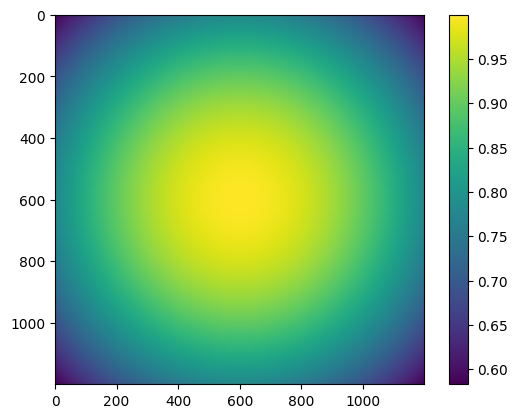

In [2]:
# beam profile on SLM to correction for beam profile

x_SLM = jnp.linspace(-N/2, N/2, N) * dx_SLM
y_SLM = jnp.linspace(-N/2, N/2, N) * dx_SLM
X_SLM, Y_SLM = jnp.meshgrid(x_SLM, y_SLM, indexing='ij')

X_SLM = X_SLM.reshape(1, 1, N, N)
Y_SLM = Y_SLM.reshape(1, 1, N, N)

beam_centered_SLM = jnp.sqrt(jnp.exp(-(X_SLM**2 + Y_SLM**2) / (2 * 4620e-6**2)))
beam_SLM = jnp.fft.ifftshift(beam_centered_SLM, axes=(-2, -1))
plt.imshow(beam_centered_SLM[0, 0, :, :])
plt.colorbar()
beam_sigma = 2000e-6
beam = jnp.fft.ifftshift(jnp.exp(-(X**2 + Y**2) / (2 * beam_sigma**2)), axes=(-2, -1))
beam_centered = jnp.exp(-(X**2 + Y**2) / (2 * beam_sigma**2))

plt.imshow(beam_centered[0, 0, :, :])

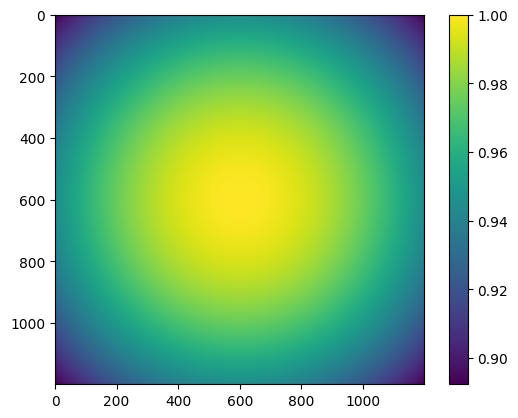

In [3]:
# beam in the image space because of vignetting, etc
beam_sigma = 3000e-6
beam_center_x = 000e-6
beam_center_y = 0e-6
beam = jnp.fft.ifftshift(jnp.exp(-(X**2 + Y**2) / (2 * beam_sigma**2)), axes=(-2, -1))

beam_centered = jnp.exp(-((X-beam_center_x)**2 + (Y-beam_center_y)**2) / (2 * beam_sigma**2)) 

plt.imshow(beam_centered[0, 0, :, :])
plt.colorbar()

# Target

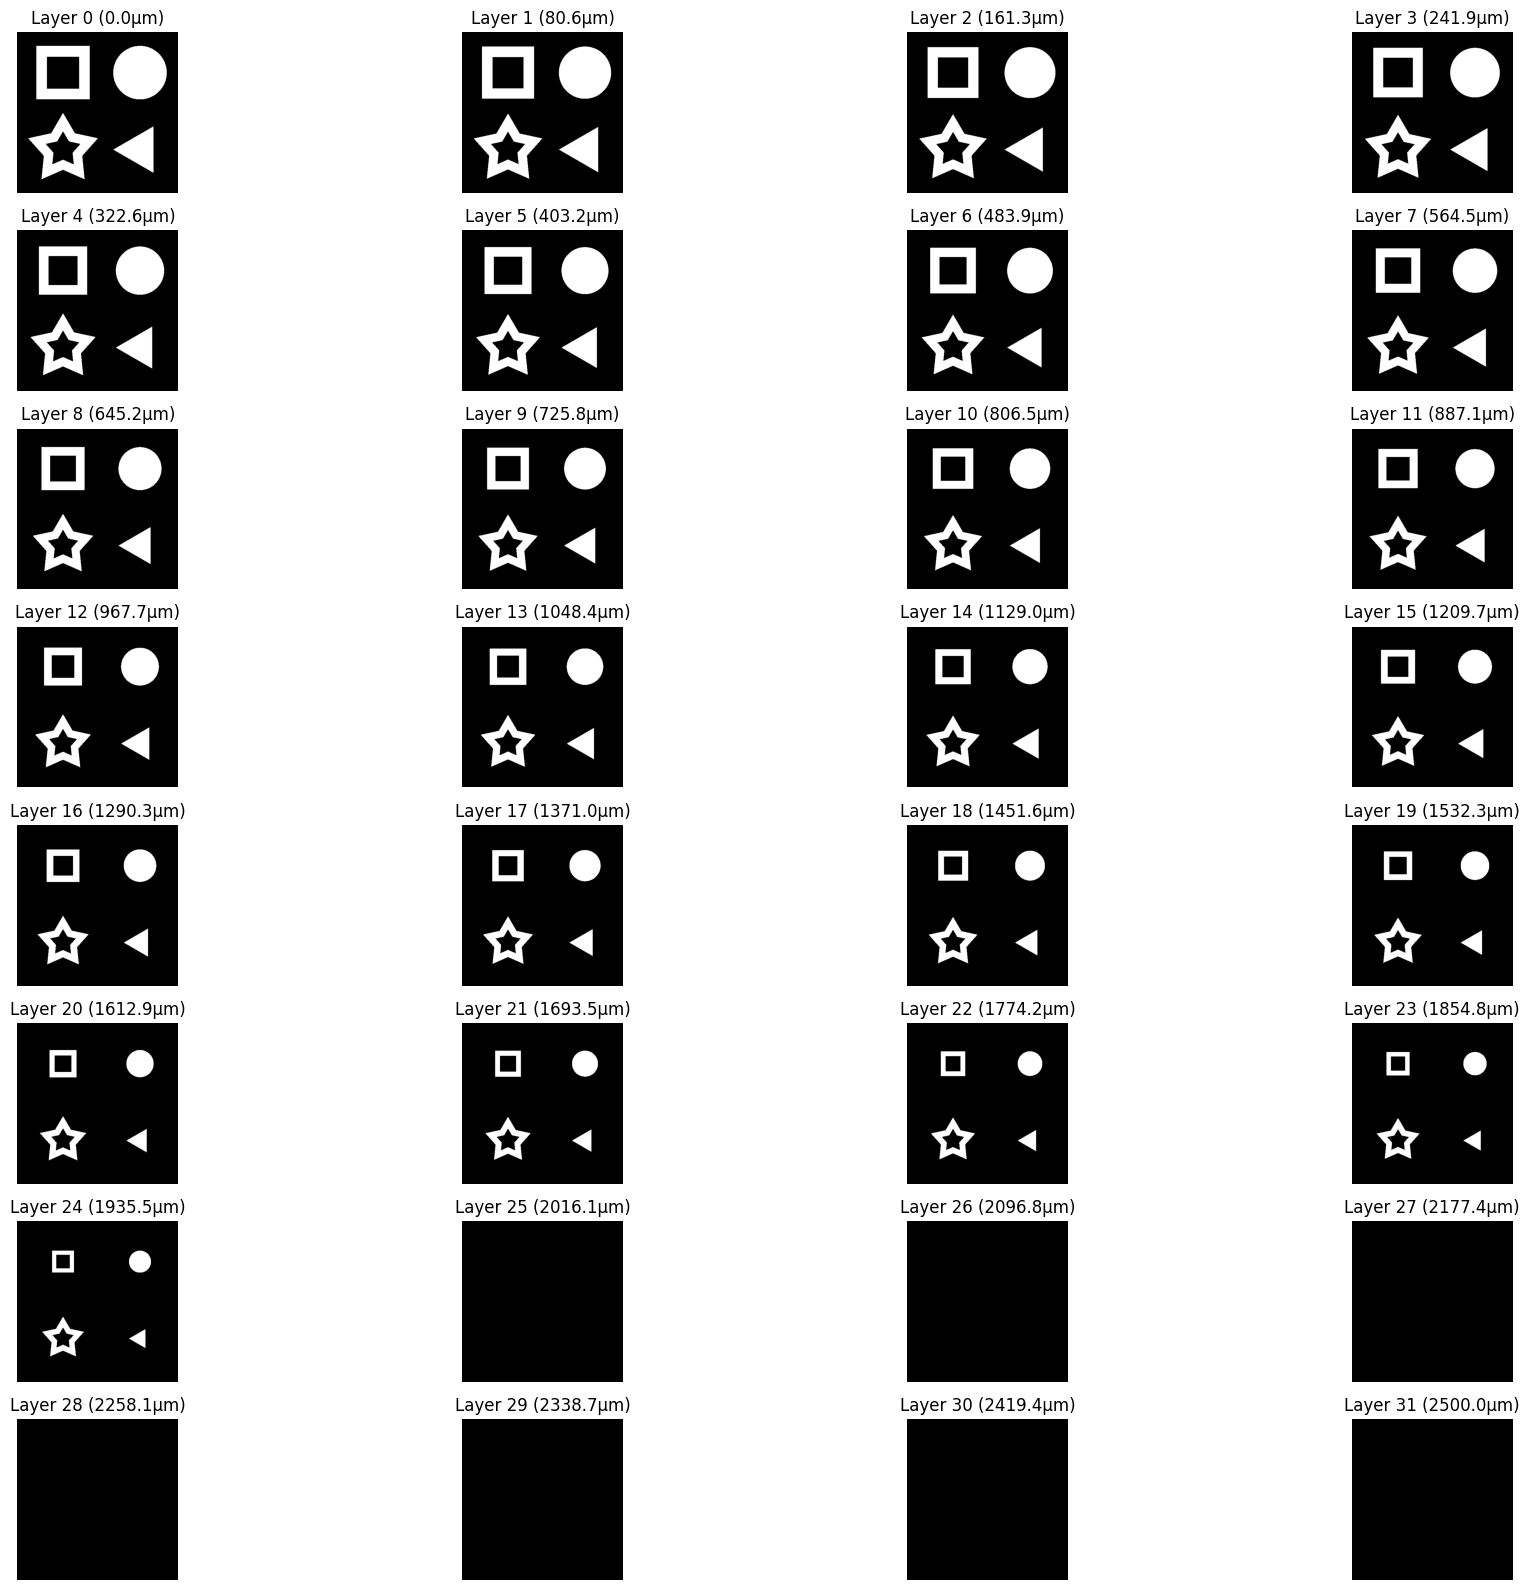

In [4]:
# target print
target = jnp.roll(np.load("target_2.npy").reshape(1, 40, 500, 500), -8,axis=1)[:, 0:Nz, :, :]
target = jnp.array(target) * (Z < 3000e-6)

fig, axes = plt.subplots(8, 4, figsize=(20, 16))
axes = axes.flatten()

for i in range(Nz):
    axes[i].imshow(target[0, i, :, :], cmap='gray')
    axes[i].set_title(f'Layer {i} ({z_distances[i]*1e6:.1f}µm)')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Optimize

Initial value: 4.96e+06 Initial gradient norm: 6.09e+02
Iteration: 0, Value: 4962857.0, Gradient norm: 608.6560668945312
Iteration: 1, Value: 1375306.375, Gradient norm: 2459.569091796875
Iteration: 2, Value: 1362613.75, Gradient norm: 1444.0311279296875
Iteration: 3, Value: 498962.96875, Gradient norm: 776.7293090820312
Iteration: 4, Value: 302916.5625, Gradient norm: 869.5057983398438
Iteration: 5, Value: 181228.5, Gradient norm: 294.3758239746094
Iteration: 6, Value: 134804.296875, Gradient norm: 243.0774688720703
Iteration: 7, Value: 95056.234375, Gradient norm: 217.0162353515625
Iteration: 8, Value: 67730.8203125, Gradient norm: 238.4664764404297
Iteration: 9, Value: 48372.98828125, Gradient norm: 125.04991912841797
Iteration: 10, Value: 38021.38671875, Gradient norm: 92.8875961303711
Iteration: 11, Value: 27032.666015625, Gradient norm: 87.7811508178711
Iteration: 12, Value: 21529.064453125, Gradient norm: 61.05567169189453
Iteration: 13, Value: 18772.47265625, Gradient norm: 37.

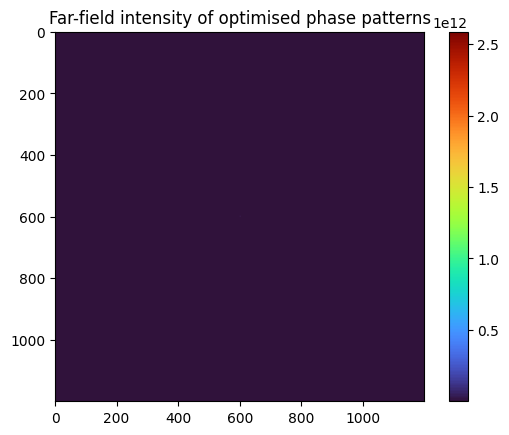

CPU times: user 29.7 s, sys: 5.22 s, total: 34.9 s
Wall time: 32.3 s


In [5]:
%%time

key = jax.random.PRNGKey(0)
# (N_patterns, z, x, y)
phases = jax.random.uniform(key, shape=(N_patterns, 1, N, N), minval=0, maxval=2 * jnp.pi) * 0.2

concentration_oxygen = 0.33040474220279514
concentration_tempo = 1 * 0.46178142653997545

concentration_oxygen_relative = concentration_oxygen / concentration_oxygen
concentration_tempo_relative = concentration_tempo / concentration_oxygen

# this needs to be hand tuned as the system is energy preserving and this corresponds
# to real power tuning of the final prints
intensity_scaling = 0.35e-7 * 5 / 8
diffusion_coefficient_oxygen = 2.3e-10
diffusion_coefficient_tempo = 1.1e-10

# print time in seconds
time_print = 8
n_medium = 1.4803
iterations = 150


def fwd_print(phases):
    dose, inhibitor_oxygen, inhibitor_tempo, intensity = forward_print_diffusion(
        phases,
        z_distances,
        wavelength,
        dx,
        target,
        beam_SLM,
        beam_centered,
        absorption_decay,
        intensity_scaling,
        n_medium,
        diffusion_coefficient_oxygen,
        diffusion_coefficient_tempo,
        time_print,
        20,
        concentration_oxygen_relative,
        concentration_tempo_relative,
    )
    return dose, inhibitor_oxygen, inhibitor_tempo, intensity


@jit
def fun(phases):
    dose, inhibitor_oxygen, inhibitor_tempo, intensity = fwd_print(phases)
    return (
          jnp.sum(target * jax.nn.relu(0.1 - dose) ** 2)
        + jnp.sum(target * jax.nn.relu(dose - 0.2) ** 2)
        + jnp.sum(target * (inhibitor_oxygen + inhibitor_tempo) ** 2)
        + jnp.sum((1 - target) * jax.nn.relu(dose) ** 2)
        + jnp.sum((1 - target) * jax.nn.relu(0.2 - inhibitor_tempo - inhibitor_oxygen) ** 2)
    )


final_phases, losses = optimize_print(phases, fun, max_iter=iterations)
final_print, inhibitor_oxygen, inhibitor_tempo, intensity_final = fwd_print(final_phases)

on_target_values = np.asarray(final_print[target > 0]).flatten()
off_target_values = np.asarray(final_print[(1 - target) > 0]).flatten()



arr = jnp.sum(
    jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(jnp.exp(1j * final_phases), axes=(-2, -1)), axes=(-2, -1))) ** 2,
    axis=(0, 1),
)
plt.imshow(arr, cmap="turbo")
plt.colorbar()
plt.title('Far-field intensity of optimised phase patterns')
plt.show()


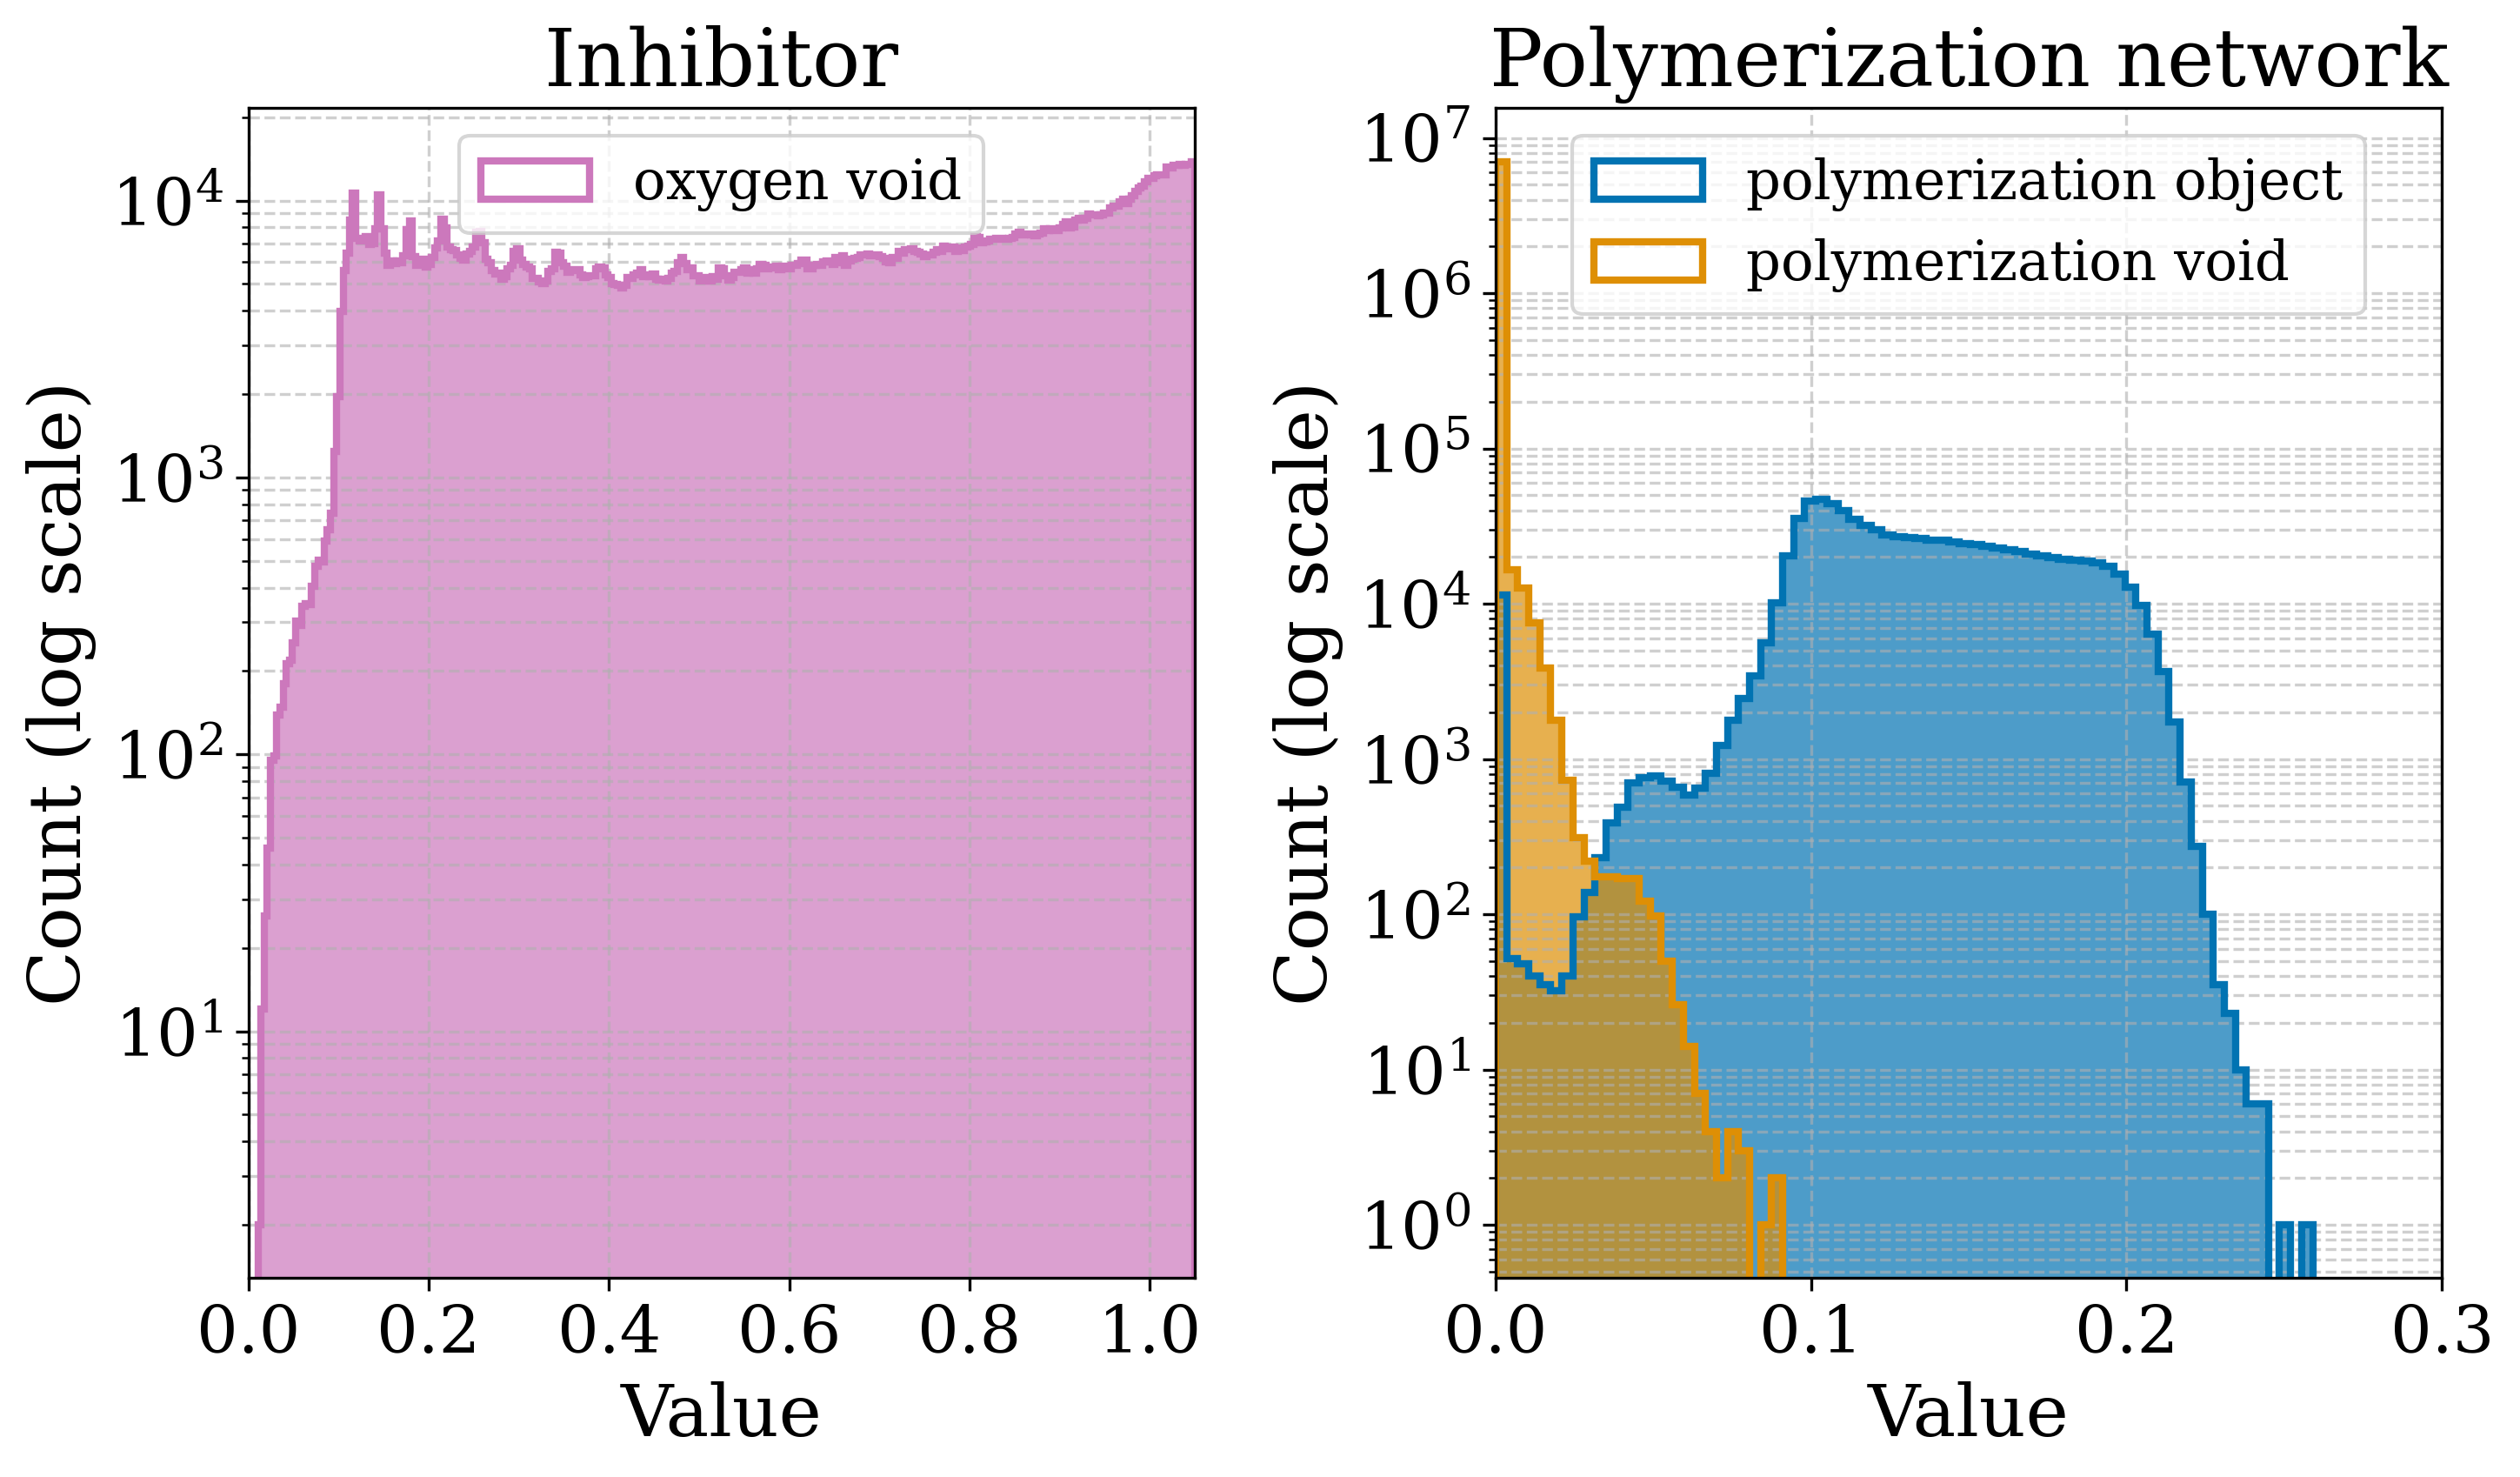

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# SIGGRAPH paper style (Times Roman for academic papers)
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['axes.titlesize'] = 22
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['legend.fontsize'] = 15

# Your data processing
on_target_values = np.asarray(final_print[target > 0]).flatten()
off_target_values = np.asarray(final_print[(1 - target) > 0]).flatten()
inhibitor_oxygen_target = np.asarray(inhibitor_oxygen[(target) > 0]).flatten()
inhibitor_oxygen_non_target = np.asarray(inhibitor_oxygen[(1 - target) > 0]).flatten()
inhibitor_tempo_target = np.asarray(inhibitor_tempo[(target) > 0]).flatten()
inhibitor_tempo_non_target = np.asarray(inhibitor_tempo[(1 - target) > 0]).flatten()
inhibitor_target = inhibitor_oxygen_target + inhibitor_tempo_target
inhibitor_non_target = inhibitor_oxygen_non_target + inhibitor_tempo_non_target

# Define the desired range and bins
plot_range = (0, 1.05)
num_bins = 300

# Colorblind-friendly palette (Okabe-Ito)
colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC']

# Create figure with two columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), dpi=300)

ax1.hist(inhibitor_non_target, bins=num_bins, range=plot_range, color=colors[3],
        alpha=0.7, log=True, histtype='stepfilled')
ax1.hist(inhibitor_non_target, bins=num_bins, range=plot_range, color=colors[3],
        log=True, histtype='step', linewidth=2, label='oxygen void')

ax1.set_xlim(plot_range)
ax1.set_xticks(np.arange(0, 1.05, 0.2))
ax1.set_xlabel('Value')
ax1.set_ylabel('Count (log scale)')
ax1.legend(loc='upper center')
ax1.grid(True, which="both", linestyle='--', alpha=0.6)
ax1.set_title('Inhibitor')

# RIGHT PLOT: Dose
ax2.hist(on_target_values, bins=num_bins, range=plot_range, color=colors[0], 
        alpha=0.7, log=True, histtype='stepfilled')
ax2.hist(off_target_values, bins=num_bins, range=plot_range, color=colors[1],
        alpha=0.7, log=True, histtype='stepfilled')

ax2.hist(on_target_values, bins=num_bins, range=plot_range, color=colors[0], 
        log=True, histtype='step', linewidth=2, label='polymerization object')
ax2.hist(off_target_values, bins=num_bins, range=plot_range, color=colors[1],
        log=True, histtype='step', linewidth=2, label='polymerization void')

ax2.set_xlim((0, 0.3))
ax2.set_xticks(np.arange(0, 0.301, 0.1))
ax2.set_xlabel('Value')
ax2.set_ylabel('Count (log scale)')
ax2.legend(loc='upper center')
ax2.grid(True, which="both", linestyle='--', alpha=0.6)
ax2.set_title('Polymerization network')

plt.tight_layout()

plt.show()

In [7]:
500 * dx

0.00084375

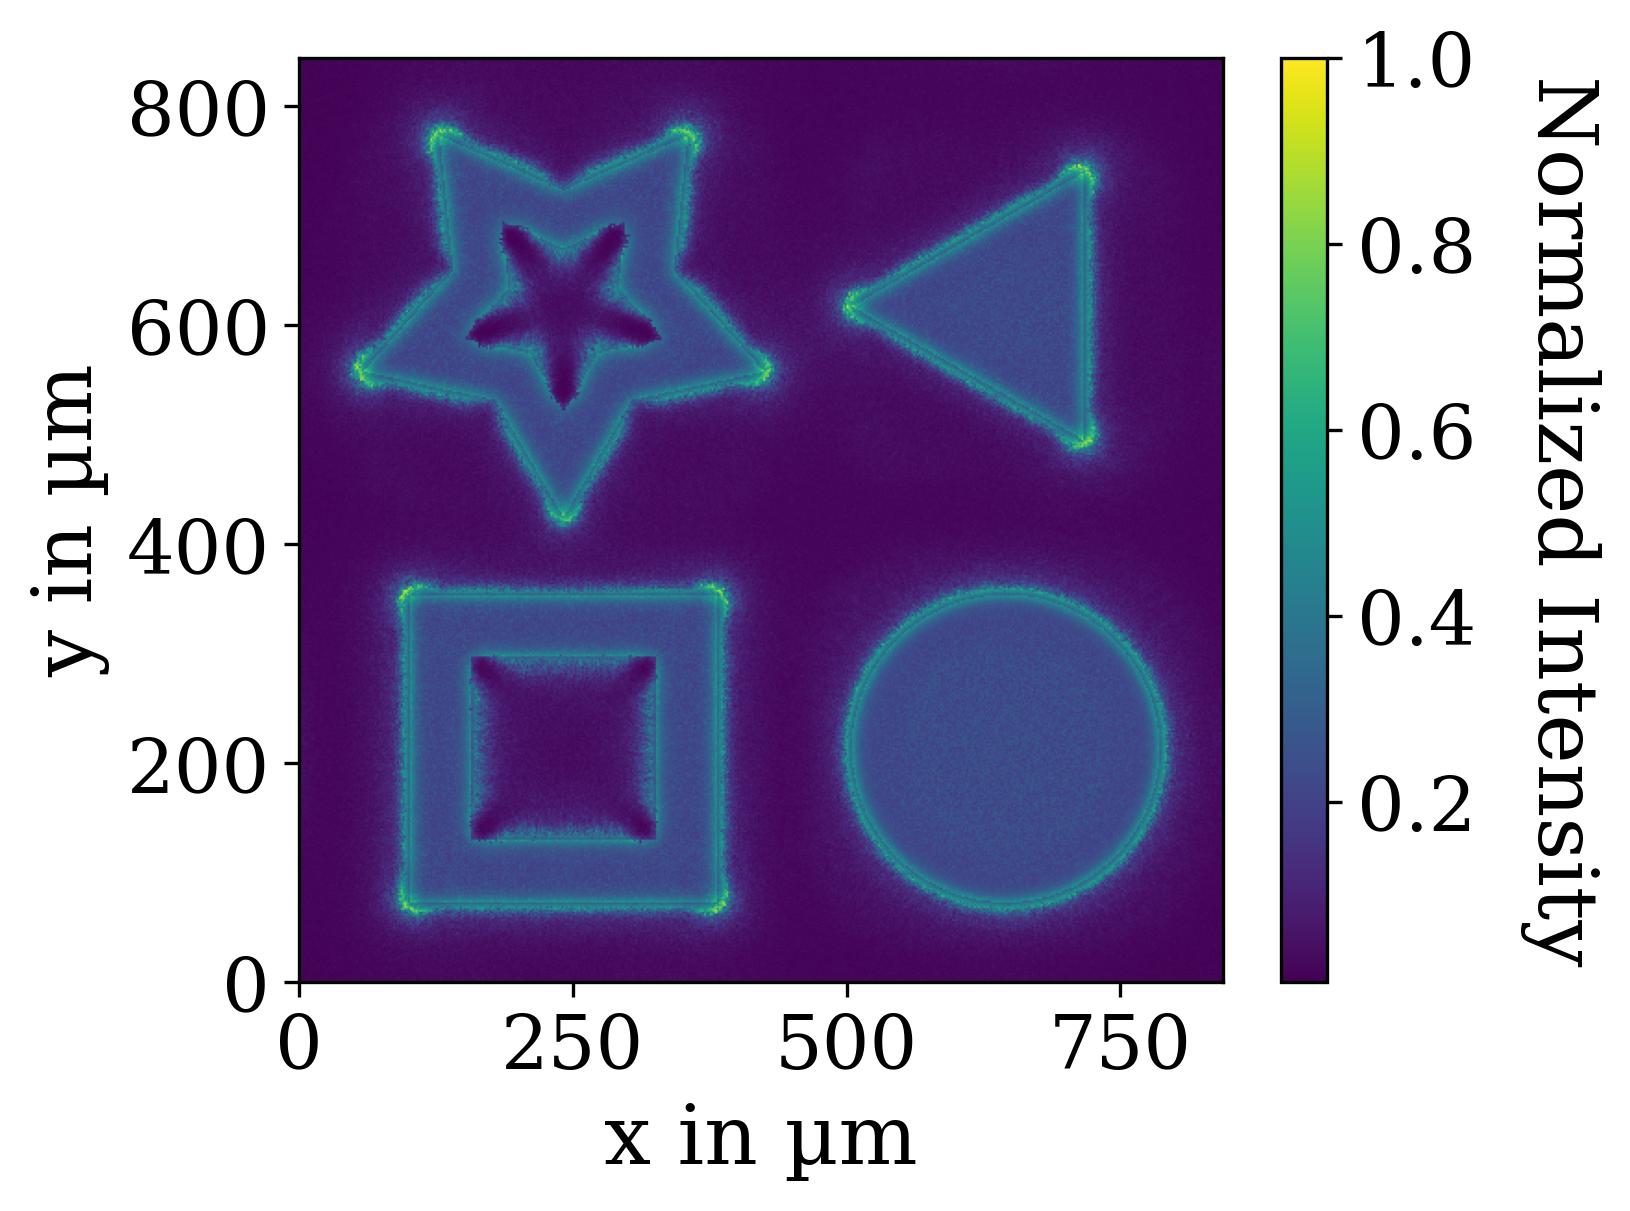

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# SIGGRAPH paper style (Times Roman for academic papers)
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['axes.titlesize'] = 22
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['ytick.labelsize'] = 18


for layer in range(intensity_final.shape[1]):
    # Crop to N_target
    arr_cropped = intensity_final[0, layer, 0:N_target, 0:N_target]
    
    # Normalize to [0, 1]
    arr_normalized = arr_cropped / np.max(arr_cropped)
    
    # Calculate physical dimensions
    extent_um = arr_cropped.shape[0] * dx * 1e6  # Convert to micrometers
    
    # Create figure
    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
    
    # Plot with colorblind-friendly colormap (viridis)
    im = ax.imshow(arr_normalized, cmap='viridis', origin='lower', 
                   extent=[0, extent_um, 0, extent_um])
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized Intensity', rotation=270, labelpad=30)
    
    # Set labels
    ax.set_xlabel('x in µm')
    ax.set_ylabel('y in µm')
    
    plt.show()

    break

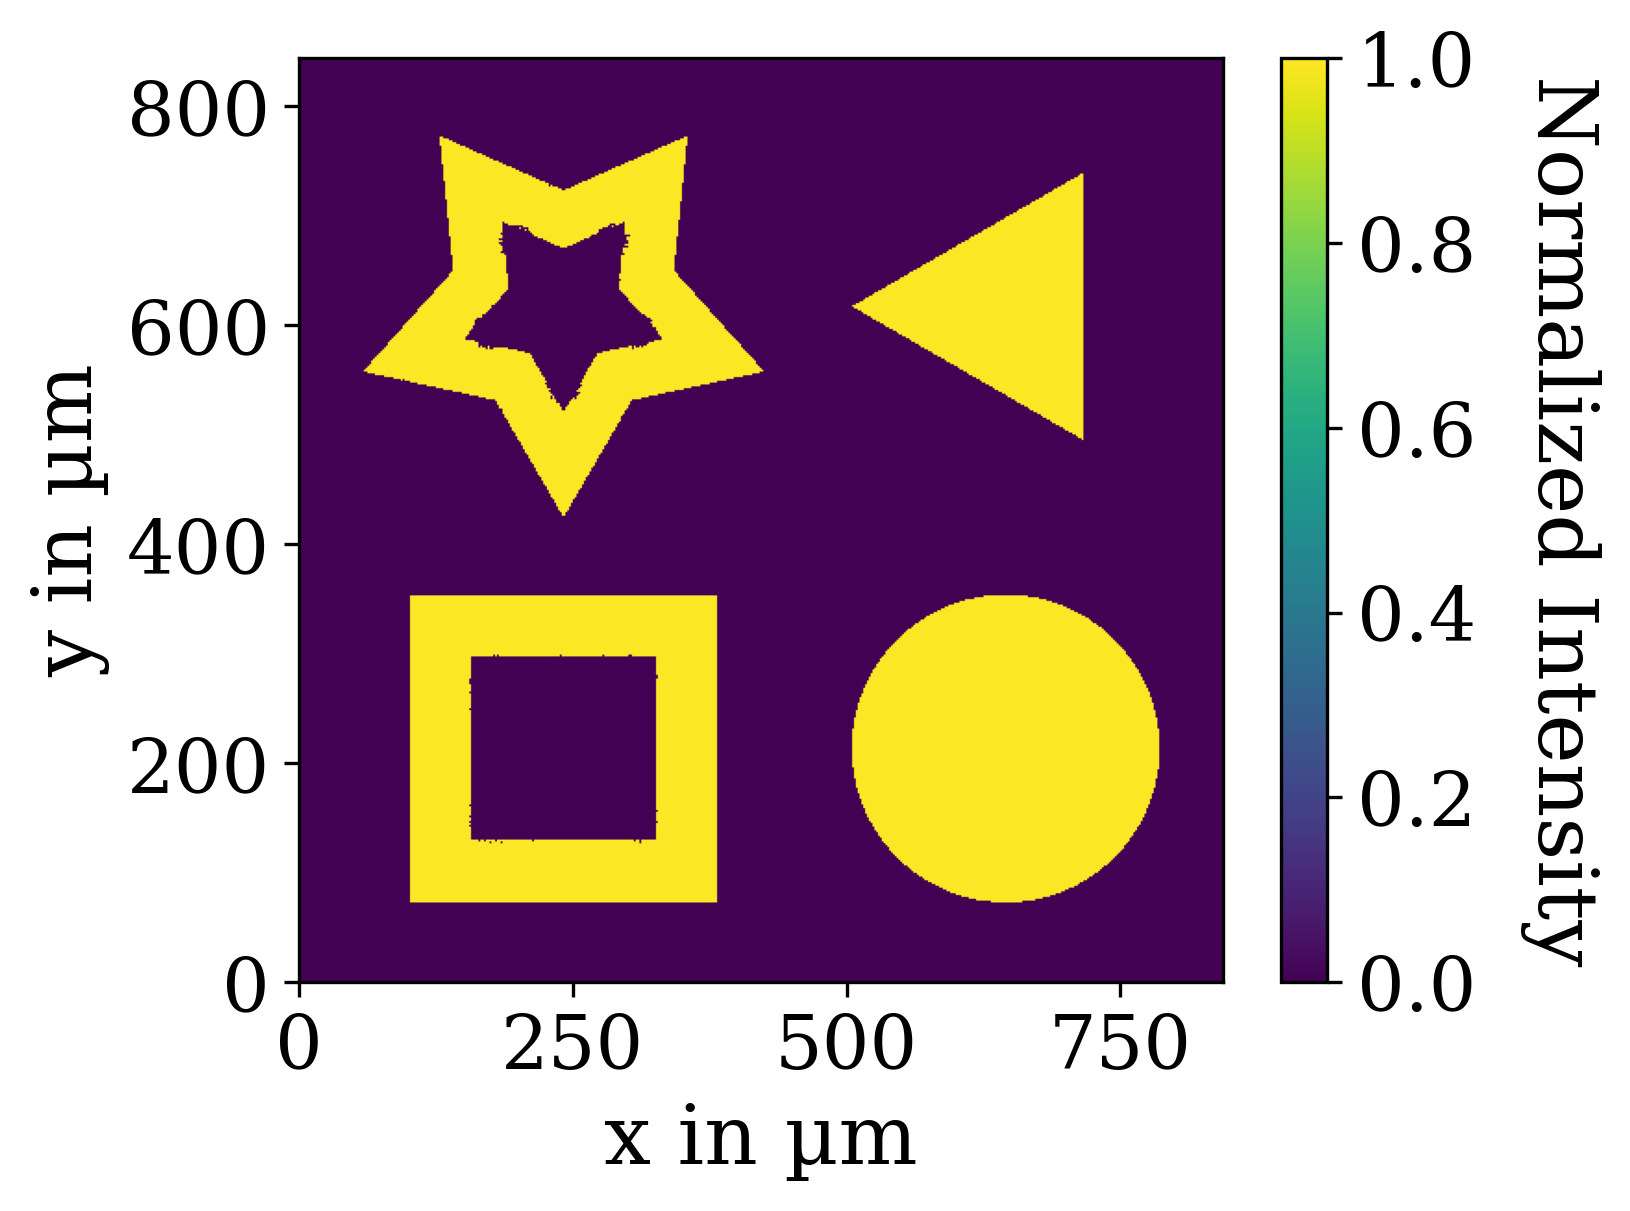

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# SIGGRAPH paper style (Times Roman for academic papers)
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['axes.titlesize'] = 22
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['ytick.labelsize'] = 18



# Crop to N_target
arr_cropped = final_print[0, 0, 0:N_target, 0:N_target] > 0.05


# Calculate physical dimensions
extent_um = arr_cropped.shape[0] * dx * 1e6  # Convert to micrometers

# Create figure
fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

# Plot with colorblind-friendly colormap (viridis)
im = ax.imshow(arr_cropped, cmap='viridis', origin='lower', 
               extent=[0, extent_um, 0, extent_um])

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Intensity', rotation=270, labelpad=30)

# Set labels
ax.set_xlabel('x in µm')
ax.set_ylabel('y in µm')

# Save with parameters in filename
plt.show()

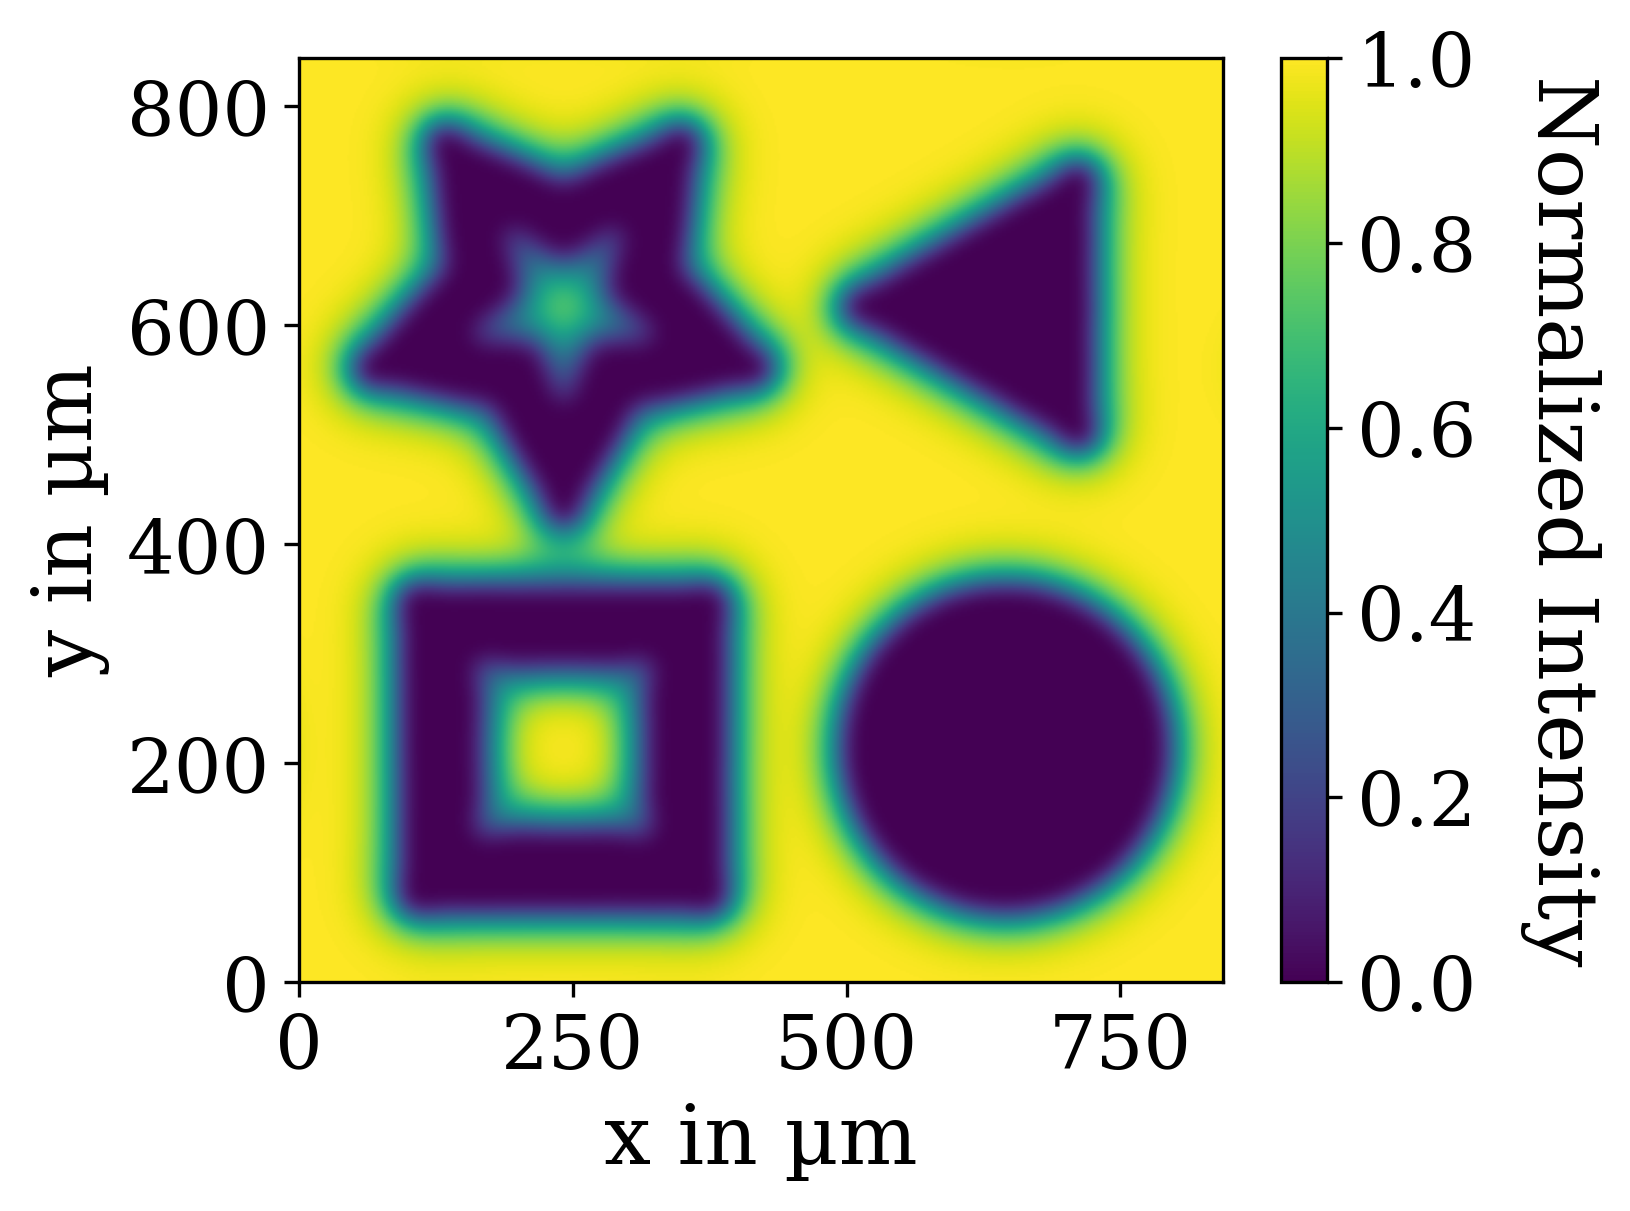

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# SIGGRAPH paper style (Times Roman for academic papers)
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['axes.titlesize'] = 22
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['ytick.labelsize'] = 18



for layer in range(intensity_final.shape[1]):
    # Crop to N_target
    arr_cropped = inhibitor_tempo[0, 0, 0:N_target, 0:N_target]
    
    # Normalize to [0, 1]
    arr_normalized = arr_cropped / np.max(arr_cropped)
    
    # Calculate physical dimensions
    extent_um = arr_cropped.shape[0] * dx * 1e6  # Convert to micrometers
    
    # Create figure
    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
    
    # Plot with colorblind-friendly colormap (viridis)
    im = ax.imshow(arr_normalized, cmap='viridis', origin='lower', 
                   extent=[0, extent_um, 0, extent_um])
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized Intensity', rotation=270, labelpad=30)
    
    # Set labels
    ax.set_xlabel('x in µm')
    ax.set_ylabel('y in µm')
    
    plt.show()
    break

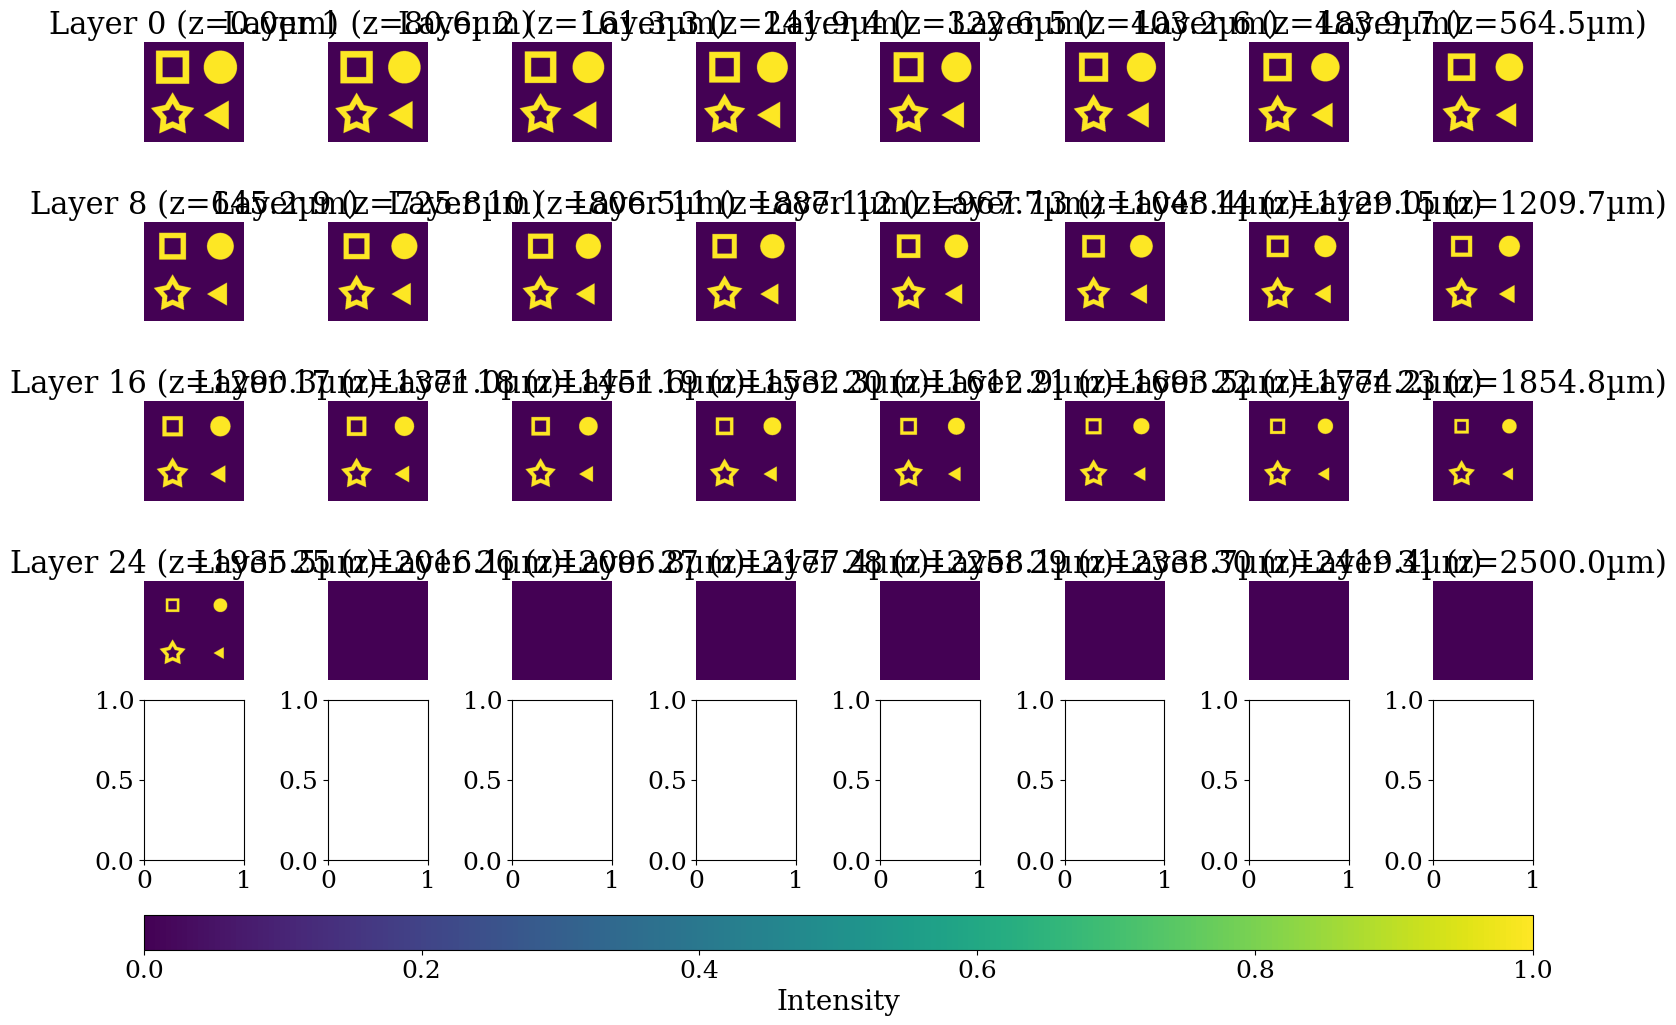

In [12]:
fig, axes = plt.subplots(5, Nz // 4, figsize=(15, 12))
axes = axes.flatten()

for i in range(Nz):
    axes[i].imshow(target[0, i, :, :] > 0.01, vmin=0.0, vmax=1, cmap='viridis')
    axes[i].set_title(f'Layer {i} (z={z_distances[i]*1e6:.1f}µm)')
    axes[i].axis('off')

plt.tight_layout()
cbar = fig.colorbar(axes[0].images[0], ax=axes, orientation='horizontal', pad=0.05, aspect=40)
cbar.set_label('Intensity')
plt.show()

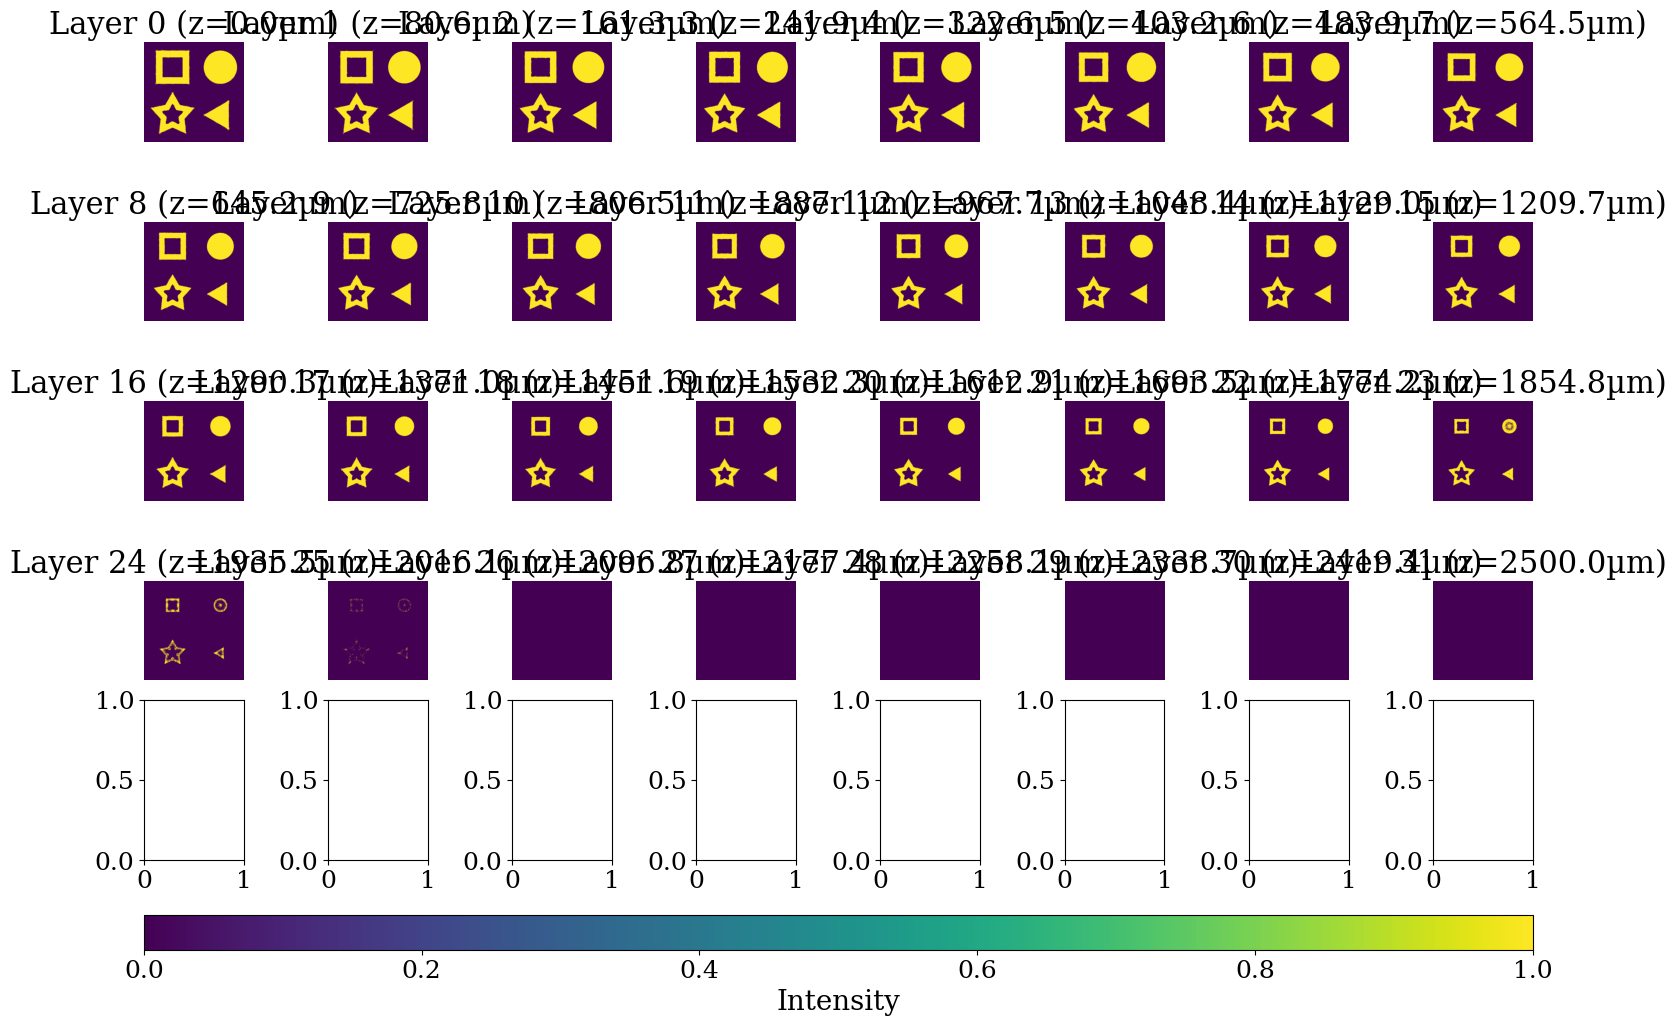

In [13]:
fig, axes = plt.subplots(5, Nz // 4, figsize=(15, 12))
axes = axes.flatten()

for i in range(Nz):
    axes[i].imshow(final_print[0, i, :, :] > 0.01, vmin=0.0, vmax=1, cmap='viridis')
    axes[i].set_title(f'Layer {i} (z={z_distances[i]*1e6:.1f}µm)')
    axes[i].axis('off')

plt.tight_layout()
cbar = fig.colorbar(axes[0].images[0], ax=axes, orientation='horizontal', pad=0.05, aspect=40)
cbar.set_label('Intensity')
plt.show()